<a href="https://colab.research.google.com/github/Reshmatr2407/Python/blob/python/19MultiplelinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multiple Linear Regression

y=m1x1+m2x2+....mnxn+b

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data=fetch_california_housing(as_frame=True)
df=data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Step 1: fill null values (here no null values)
Step 2 :  encoding ( here all values are numerical)

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Step 3: Find Outliers ( Remove outliers is necessary)

<Axes: >

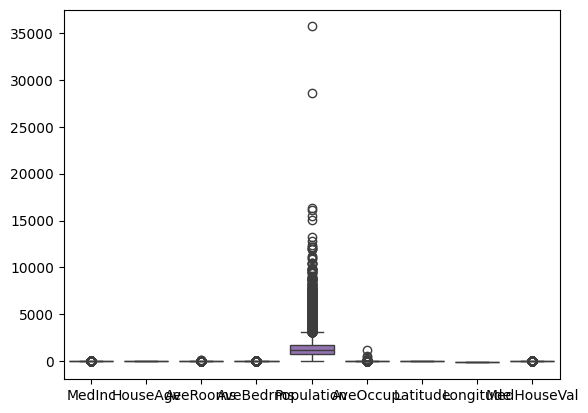

In [ ]:
sns.boxplot(df)

Step 4 : Draw Corelation matrix

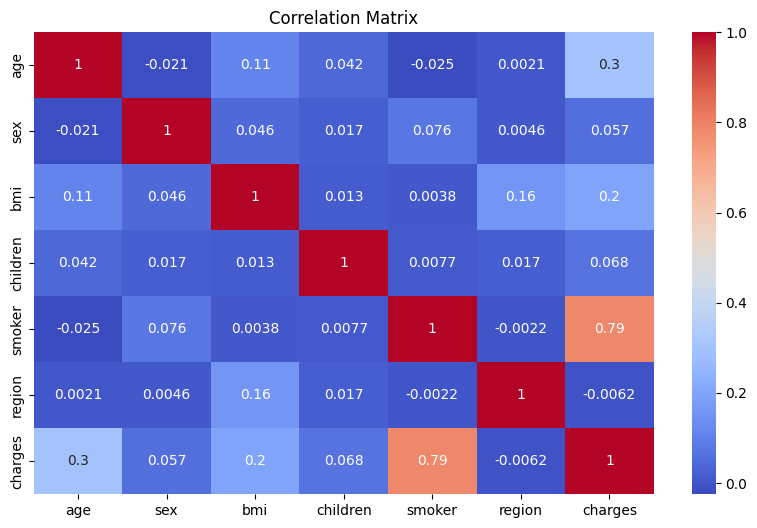

In [ ]:
import matplotlib.pyplot as plt
corr=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,cmap="coolwarm",annot=True)
plt.title("Correlation Matrix")
plt.show()

( As avg_rooms and avg_bedroom have high corelation remove any one based on its corelation with y)

Step 5: split x  (features )and y(target)

In [ ]:
x=df.drop("MedHouseVal",axis=1)
y=df["MedHouseVal"]

KeyError: "['MedHouseVal'] not found in axis"

Step 6. Standard sacling may lead to data leakage
So do it after train_test split

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# Standard scaling

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

Step 7 : Multiple Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
y_pred=model.predict(x_test_scaled)

print("MAE  :  ",mean_absolute_error(y_test,y_pred))
print("RMSE  :  ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2  :  ",r2_score(y_test,y_pred))

MAE  :   0.5332001304956565
RMSE  :   0.7455813830127763
R2  :   0.575787706032451


As error are close to 1 its ok.

In [ ]:
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print("Enter house details")
medinc=float(input("Median Income   : "))
houseage=float(input("House Age   : "))
averooms=float(input("Average rooms     :  "))
avebedrooms=float(input("Average bedrooms     :  "))
population=float(input("Population   :  "))
avgoccupation=float(input("Average Occupation   :  "))
latitude=float(input("Latitude   :  "))
longitude=float(input("Longitude   :   "))


Enter house details
Median Income   : 8.3252
House Age   : 41.0
Average rooms     :  6.984127
Average bedrooms     :  1.023810
Population   :  322.0
Average Occupation   :  2.555556
Latitude   :  37.88
Longitude   :   -122.23


In [ ]:
user_data=pd.DataFrame([[
    medinc,houseage,averooms,avebedrooms,population,avgoccupation,latitude,longitude
]],columns=x.columns)

ValueError: 6 columns passed, passed data had 8 columns

In [ ]:
user_data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23


In [ ]:
user_data_scaled=sc.transform(user_data)
predicted_price=model.predict(user_data_scaled)
print("Predicted Median House Value  ",predicted_price[0])
print("Predicted Price  :  ",predicted_price[0]*100000)

Predicted Median House Value   83.9980582258841
Predicted Price  :   8399805.82258841


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Example 2%%%%%%%%%%%%new data set


In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df['sex'].nunique()

2

In [ ]:
df['smoker'].nunique()

2

In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
df['region']=le.fit_transform(df['region'])

In [ ]:
df['sex']=le.fit_transform(df['sex'])

In [ ]:
df['smoker']=le.fit_transform(df['smoker'])

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


<Axes: >

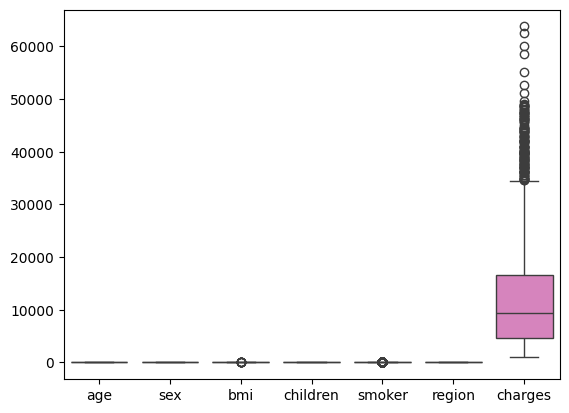

In [ ]:
sns.boxplot(df)

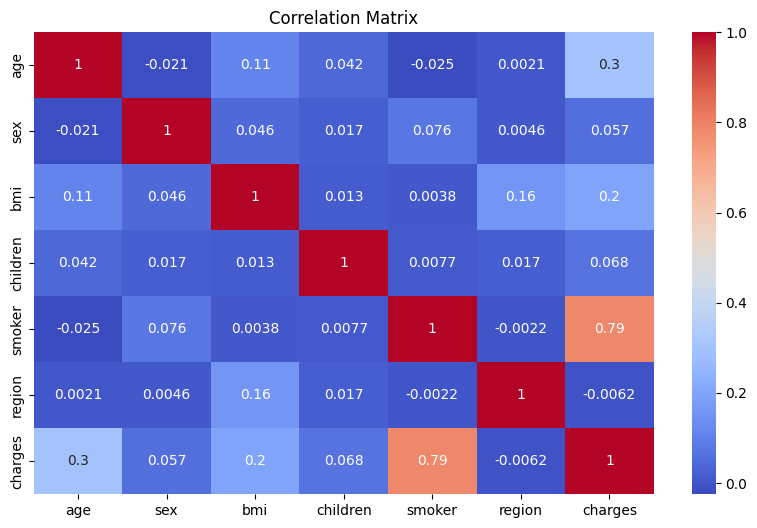

In [ ]:
import matplotlib.pyplot as plt
corr=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,cmap="coolwarm",annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


In [ ]:
x=df.drop("charges",axis=1)
y=df["charges"]

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# Standard scaling

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
y_pred=model.predict(x_test_scaled)

print("MAE  :  ",mean_absolute_error(y_test,y_pred))
print("RMSE  :  ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2  :  ",r2_score(y_test,y_pred))

MAE  :   4186.508898366436
RMSE  :   5799.5870914383595
R2  :   0.7833463107364536


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
print("Enter  details")
age=float(input("age  : "))
sex=float(input("sex   : "))
bmi=float(input("bmi    :  "))
children=float(input("children    :  "))
smoker=float(input("smoker    :  "))
region=float(input("region   :  "))


Enter  details
age  : 19
sex   : 0
bmi    :  27.900
children    :  0
smoker    :  1
region   :  3


In [ ]:
user_data=pd.DataFrame([[
    age,sex,bmi,children,smoker,region
]],columns=x.columns)

In [ ]:
user_data_scaled=sc.transform(user_data)
predicted_price=model.predict(user_data_scaled)
print("Charges  ",predicted_price[0])


Charges   25139.73133877761
